In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = {
    "branch": ["Atlanta", "Boston", "Chicago", "Dallas",
               "Denver", "Houston", "Miami", "Nashville",
               "Phoenix", "Portland", "Seattle", "Tampa"],
    "revenue_usd": [142000, 198000, 175000, 161000,
                    134000, 189000, 210000, 123000,
                    155000, 168000, 202000, 139000],
    "units_sold": [940, 1280, 1105, 1020,
                   870, 1190, 1340, 790,
                   985, 1060, 1295, 855],
    "return_rate_pct": [3.1, 2.4, 2.9, 4.2,
                        3.8, 2.1, 1.9, 5.1,
                        3.4, 2.7, 2.2, 4.6]
}

df = pd.DataFrame(data)
print(df.head())

    branch  revenue_usd  units_sold  return_rate_pct
0  Atlanta       142000         940              3.1
1   Boston       198000        1280              2.4
2  Chicago       175000        1105              2.9
3   Dallas       161000        1020              4.2
4   Denver       134000         870              3.8


In [2]:
revenue = df["revenue_usd"]

mean_rev   = revenue.mean()
median_rev = revenue.median()

print(f"Mean revenue:   ${mean_rev:,.0f}")
print(f"Median revenue: ${median_rev:,.0f}")

Mean revenue:   $166,333
Median revenue: $164,500


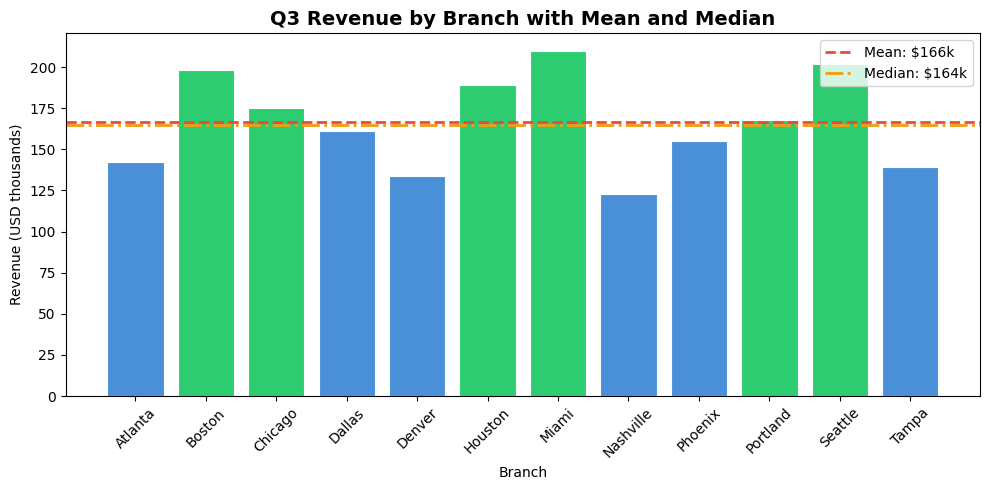

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#4a90d9" if v < mean_rev else "#2ecc71"
          for v in df["revenue_usd"]]

ax.bar(df["branch"], df["revenue_usd"] / 1000,
       color=colors, edgecolor="white", linewidth=0.8)

ax.axhline(mean_rev / 1000, color="#e74c3c", linewidth=2,
           linestyle="--", label=f"Mean: ${mean_rev/1000:.0f}k")
ax.axhline(median_rev / 1000, color="#f39c12", linewidth=2,
           linestyle="-.", label=f"Median: ${median_rev/1000:.0f}k")

ax.set_title("Q3 Revenue by Branch with Mean and Median",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Branch")
ax.set_ylabel("Revenue (USD thousands)")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("revenue_central_tendency.png", dpi=150)
plt.show()

In [4]:
std_rev   = revenue.std()
var_rev   = revenue.var()
range_rev = revenue.max() - revenue.min()
iqr_rev   = revenue.quantile(0.75) - revenue.quantile(0.25)

print(f"Std deviation: ${std_rev:,.0f}")
print(f"Variance:      ${var_rev:,.0f}")
print(f"Range:         ${range_rev:,.0f}")
print(f"IQR:           ${iqr_rev:,.0f}")

Std deviation: $28,908
Variance:      $835,696,970
Range:         $87,000
IQR:           $50,000


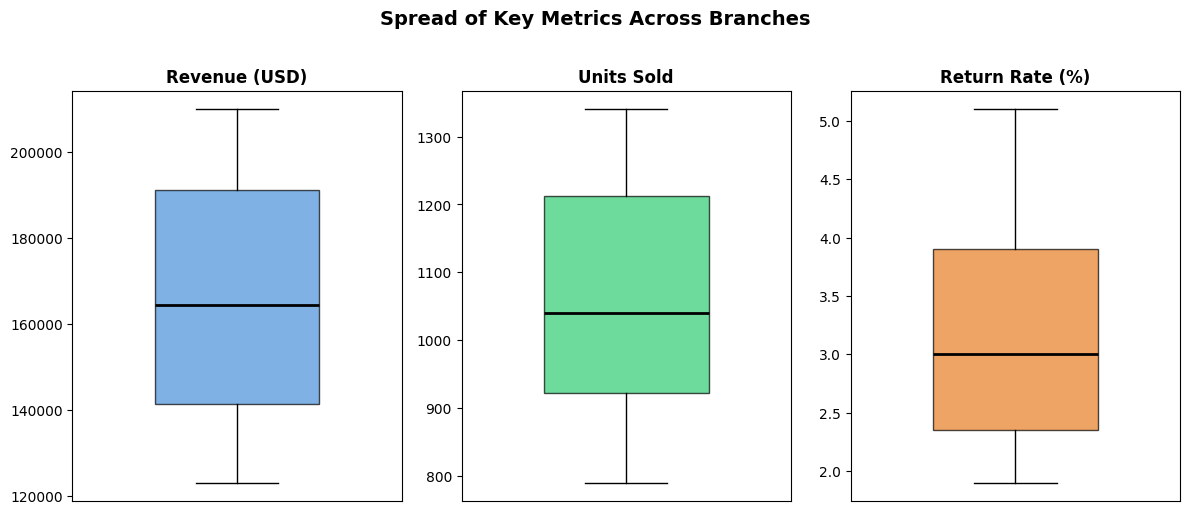

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

cols   = ["revenue_usd", "units_sold", "return_rate_pct"]
labels = ["Revenue (USD)", "Units Sold", "Return Rate (%)"]
colors = ["#4a90d9", "#2ecc71", "#e67e22"]

for ax, col, label, color in zip(axes, cols, labels, colors):
    bp = ax.boxplot(df[col], patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor(color)
    bp["boxes"][0].set_alpha(0.7)
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xticks([])

plt.suptitle("Spread of Key Metrics Across Branches",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots_spread.png", dpi=150)
plt.show()

In [6]:
print(df[["revenue_usd", "units_sold", "return_rate_pct"]].describe().round(2))

       revenue_usd  units_sold  return_rate_pct
count        12.00       12.00            12.00
mean     166333.33     1060.83             3.20
std       28908.42      184.29             1.04
min      123000.00      790.00             1.90
25%      141250.00      922.50             2.35
50%      164500.00     1040.00             3.00
75%      191250.00     1212.50             3.90
max      210000.00     1340.00             5.10


In [7]:
for col in ["revenue_usd", "units_sold", "return_rate_pct"]:
    skew = df[col].skew()
    print(f"{col:<25} skewness = {skew:.3f}")

revenue_usd               skewness = 0.095
units_sold                skewness = 0.167
return_rate_pct           skewness = 0.549


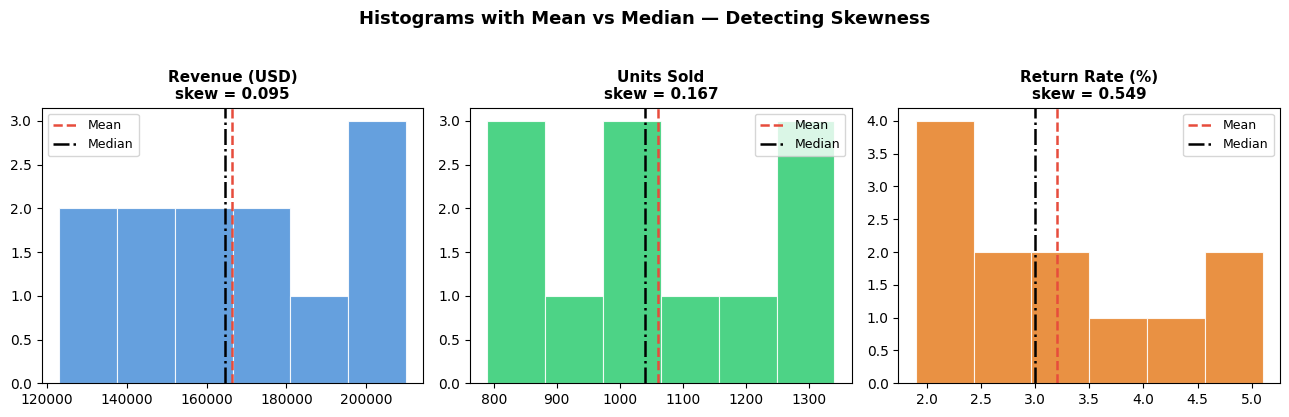

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

cols   = ["revenue_usd", "units_sold", "return_rate_pct"]
labels = ["Revenue (USD)", "Units Sold", "Return Rate (%)"]
colors = ["#4a90d9", "#2ecc71", "#e67e22"]

for ax, col, label, color in zip(axes, cols, labels, colors):
    ax.hist(df[col], bins=6, color=color, edgecolor="white",
            linewidth=0.8, alpha=0.85)

    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color="#e74c3c", linestyle="--",
               linewidth=1.8, label="Mean")
    ax.axvline(median_val, color="black",   linestyle="-.",
               linewidth=1.8, label="Median")

    skew_val = df[col].skew()
    ax.set_title(f"{label}\nskew = {skew_val:.3f}",
                 fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Histograms with Mean vs Median — Detecting Skewness",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("histograms_skewness.png", dpi=150)
plt.show()

In [9]:
def summarize(series, label):
    print(f"\n── {label} ──")
    print(f"  Mean:    {series.mean():>10.2f}")
    print(f"  Median:  {series.median():>10.2f}")
    print(f"  Std Dev: {series.std():>10.2f}")
    print(f"  IQR:     {series.quantile(0.75) - series.quantile(0.25):>10.2f}")
    print(f"  Skew:    {series.skew():>10.3f}")

summarize(df["revenue_usd"],     "Revenue (USD)")
summarize(df["units_sold"],      "Units Sold")
summarize(df["return_rate_pct"], "Return Rate (%)")


── Revenue (USD) ──
  Mean:     166333.33
  Median:   164500.00
  Std Dev:   28908.42
  IQR:       50000.00
  Skew:         0.095

── Units Sold ──
  Mean:       1060.83
  Median:     1040.00
  Std Dev:     184.29
  IQR:         290.00
  Skew:         0.167

── Return Rate (%) ──
  Mean:          3.20
  Median:        3.00
  Std Dev:       1.04
  IQR:           1.55
  Skew:         0.549
